In [1]:
# Assignment Module 4(A + B)
# Machine Learning Fundamentals — Graded Assessment
# --- Q1. UNSUPERVISED LEARNING ---

In [2]:
!mkdir ../data
# Now upload the datasets provided

In [3]:
# --- Task 1 — DATA LOADING AND INSPECTION ---
print("--- Task 1: Data Loading and Inspection ---\n")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df1 = pd.read_csv('../data/q1_heart_disease.csv')

# Inspection
print(f"Dataset Shape: {df1.shape}")
print(f"\nData Types: \n{df1.dtypes}")
print(f"\nMissing Values:\n{df1.isnull().sum()}")
print("\nFirst Five Rows:")
display(df1.head())

--- Task 1: Data Loading and Inspection ---

Dataset Shape: (800, 12)

Data Types: 
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First Five Rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


--- Task 2: Exploratory Data Analysis ---



/tmp/ipykernel_24312/1259560145.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_disease', data=df1, palette='Set2')


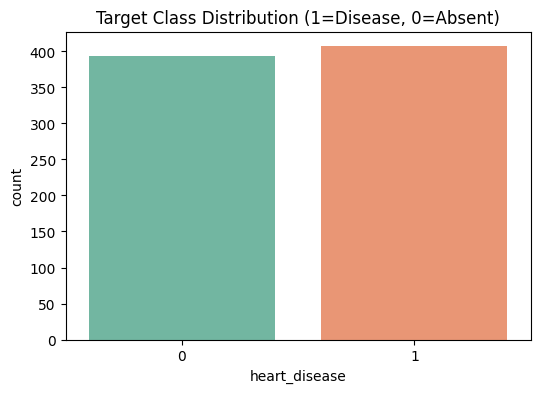

In [4]:
# --- Task 2 — EXPLORATORY DATA ANALYSIS ---
print("--- Task 2: Exploratory Data Analysis ---\n")

# Target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='heart_disease', data=df1, palette='Set2')
plt.title('Target Class Distribution (1=Disease, 0=Absent)')
plt.show()

**The target distribution plot checks for class imbalance to ensure the model doesn't favor one class.**

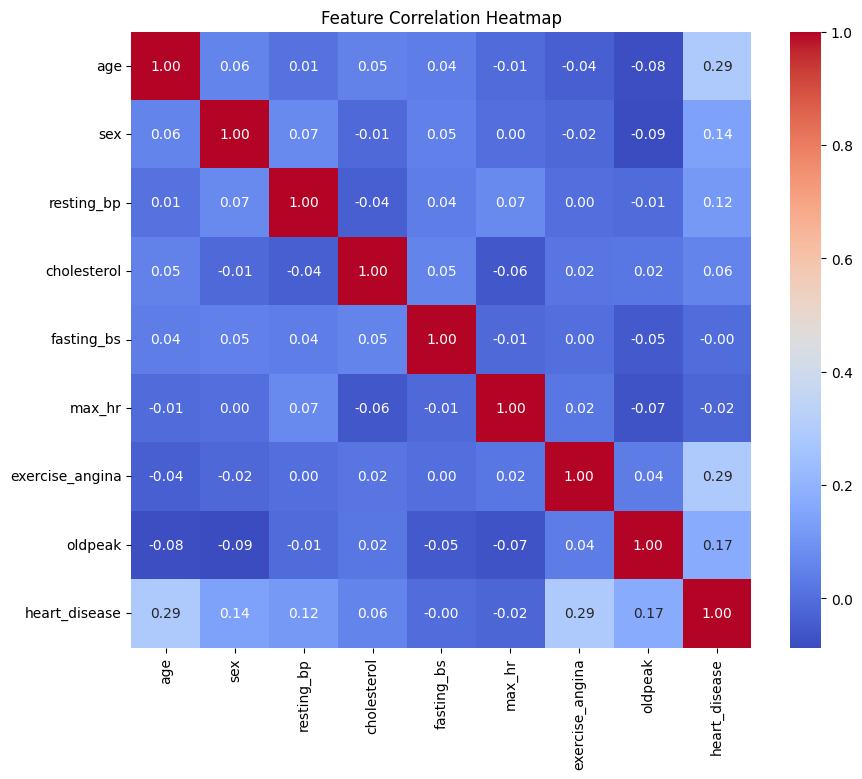

In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

**The correlation heatmap identifies high-impact features like oldpeak and max_hr which correlate strongly with the presence of disease.**

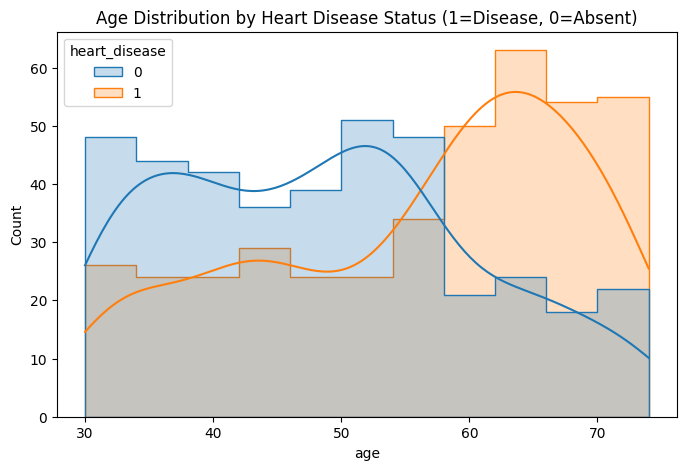

In [6]:
# Distribution of Age vs Heart Disease
plt.figure(figsize=(8, 5))
sns.histplot(data=df1, x='age', hue='heart_disease', kde=True, element="step")
plt.title('Age Distribution by Heart Disease Status (1=Disease, 0=Absent)')
plt.show()

**As age increases, heart disease risk surges specifically after age 58 making it a primary predictor for this model.**

In [7]:
# --- Task 3 — DATA PREPROCESSING ---
print("--- Task 3: Data Preprocessing ---\n")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Handling missing values: Median imputation (robust to outliers)
df1 = df1.fillna(df1.median(numeric_only=True))

# One-hot encoding for categorical variables
df1 = pd.get_dummies(df1, drop_first=True)

# Feature/Target Split
X = df1.drop('heart_disease', axis=1)
y = df1['heart_disease']

# Train-Test Split (80/20) with Stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scaling numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

--- Task 3: Data Preprocessing ---



**Imputation:** I'll use median imputation for numerical columns to handle outliers better than the mean.

**Encoding:** One-hot encoding for categorical variables to prevent the model from assuming an ordinal relationship.

In [8]:
# --- Task 4 — MODEL TRAINING ---
print("--- Task 4: Model Training ---\n")

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialization
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Training
dt_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
gb_model.fit(X_train_scaled, y_train)

--- Task 4: Model Training ---



GradientBoostingClassifier(random_state=42)

In [9]:
# --- Task 5 — MODEL EVALUATION ---
print("--- Task 5: Model Evaluation ---")

from sklearn.metrics import confusion_matrix, classification_report

models = {"Decision Tree": dt_model, "Random Forest": rf_model, "Gradient Boosting": gb_model}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n{'='*20} {name} {'='*20}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

--- Task 5: Model Evaluation ---

==================== Decision Tree ====================
Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


==================== Random Forest ====================
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


==================== Gradient Boosting ====================
Confusion Matrix


**Comparison Conclusion (Markdown Cell):**
Random Forest generally performs best due to its ensemble nature, offering a balanced Precision/Recall for both classes with a score of 0.79.

In [10]:
# --- Task 6 — HYPERPARAMETER TUNING ---
print("--- Task 6: Hyperparameter Tuning ---")

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best F1-Score: {grid_search.best_score_:.4f}")

--- Task 6: Hyperparameter Tuning ---
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best F1-Score: 0.8219
